In [89]:
print("\nRESULTADO FINAL")

print(
    "CV accuracy:",
    np.mean(scores_majority)
)

print(
    "CV std:",
    np.std(scores_majority)
)

print(
    "Train accuracy:",
    np.mean(train_scores_majority)
)

print(
    "Média de linhas antes:",
    np.mean(linhas_antes)
)

print(
    "Média de textos após consolidação:",
    np.mean(linhas_depois)
)

print(
    "Média de empates removidos:",
    np.mean(empates_por_fold)
)


RESULTADO FINAL
CV accuracy: 0.4529966035034486
CV std: 0.007080097459903325
Train accuracy: 0.6902933006637078
Média de linhas antes: 12858.4
Média de textos após consolidação: 11680.8
Média de empates removidos: 100.8


In [88]:
from sklearn.base import clone
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd

scores_majority = []
train_scores_majority = []
linhas_antes = []
linhas_depois = []
empates_por_fold = []

for fold, (idx_tr, idx_va) in enumerate(
    cv_final_k.split(
        train_df["resp_text"].astype(str),
        train_df["clarity"],
        train_df["text_group"]
    ),
    start=1
):

    fold_train = train_df.iloc[idx_tr].copy()
    fold_val = train_df.iloc[idx_va].copy()

    linhas_antes.append(len(fold_train))

    # Contagem de cada label para cada texto
    contagens = (
        fold_train
        .groupby(["resp_text", "clarity"])
        .size()
        .unstack(fill_value=0)
    )

    # Detecta empates na maior contagem
    max_count = contagens.max(axis=1)

    n_maximos = contagens.eq(
        max_count,
        axis=0
    ).sum(axis=1)

    textos_sem_empate = contagens[
        n_maximos == 1
    ]

    empates = (n_maximos > 1).sum()
    empates_por_fold.append(empates)

    # Label majoritário
    labels_majoritarios = (
        textos_sem_empate
        .idxmax(axis=1)
        .rename("clarity")
    )

    # Um registro por texto
    fold_train_majority = (
        labels_majoritarios
        .reset_index()
    )

    linhas_depois.append(
        len(fold_train_majority)
    )

    modelo = clone(melhor_pipeline)

    modelo.fit(
        fold_train_majority["resp_text"].astype(str),
        fold_train_majority["clarity"]
    )

    pred_val = modelo.predict(
        fold_val["resp_text"].astype(str)
    )

    pred_train = modelo.predict(
        fold_train_majority["resp_text"].astype(str)
    )

    acc_val = accuracy_score(
        fold_val["clarity"],
        pred_val
    )

    acc_train = accuracy_score(
        fold_train_majority["clarity"],
        pred_train
    )

    scores_majority.append(acc_val)
    train_scores_majority.append(acc_train)

    print(
        f"Fold {fold}: "
        f"val={acc_val:.4f} | "
        f"train={acc_train:.4f} | "
        f"antes={len(fold_train)} | "
        f"depois={len(fold_train_majority)} | "
        f"empates={empates}"
    )

Fold 1: val=0.4582 | train=0.6907 | antes=12858 | depois=11670 | empates=98
Fold 2: val=0.4592 | train=0.6891 | antes=12861 | depois=11679 | empates=110
Fold 3: val=0.4512 | train=0.6886 | antes=12855 | depois=11660 | empates=106
Fold 4: val=0.4400 | train=0.6895 | antes=12859 | depois=11689 | empates=100
Fold 5: val=0.4564 | train=0.6936 | antes=12859 | depois=11706 | empates=90


In [87]:
print("\nRESULTADO FINAL")

print(
    "CV accuracy:",
    np.mean(scores_limpo)
)

print(
    "CV std:",
    np.std(scores_limpo)
)

print(
    "Train accuracy:",
    np.mean(train_scores_limpo)
)

print(
    "Média de linhas removidas por fold:",
    np.mean(removidos_por_fold)
)


RESULTADO FINAL
CV accuracy: 0.45193710579792645
CV std: 0.007693267227417461
Train accuracy: 0.6943953225818109
Média de linhas removidas por fold: 1100.0


In [86]:
from sklearn.base import clone
from sklearn.metrics import accuracy_score
import numpy as np

scores_limpo = []
train_scores_limpo = []
removidos_por_fold = []

X = train_df["resp_text"].astype(str)
y = train_df["clarity"]
groups = train_df["text_group"]

for fold, (idx_tr, idx_va) in enumerate(
    cv_final_k.split(X, y, groups),
    start=1
):
    fold_train = train_df.iloc[idx_tr].copy()
    fold_val = train_df.iloc[idx_va].copy()

    # Identifica textos conflitantes APENAS no treino deste fold
    n_labels = (
        fold_train
        .groupby("resp_text")["clarity"]
        .nunique()
    )

    textos_conflitantes_fold = set(
        n_labels[n_labels > 1].index
    )

    # Remove do treinamento os textos ambíguos
    fold_train_limpo = fold_train[
        ~fold_train["resp_text"].isin(textos_conflitantes_fold)
    ].copy()

    removidos = len(fold_train) - len(fold_train_limpo)
    removidos_por_fold.append(removidos)

    modelo = clone(melhor_pipeline)

    modelo.fit(
        fold_train_limpo["resp_text"].astype(str),
        fold_train_limpo["clarity"]
    )

    pred_val = modelo.predict(
        fold_val["resp_text"].astype(str)
    )

    pred_train = modelo.predict(
        fold_train_limpo["resp_text"].astype(str)
    )

    acc_val = accuracy_score(
        fold_val["clarity"],
        pred_val
    )

    acc_train = accuracy_score(
        fold_train_limpo["clarity"],
        pred_train
    )

    scores_limpo.append(acc_val)
    train_scores_limpo.append(acc_train)

    print(
        f"Fold {fold}: "
        f"val={acc_val:.4f} | "
        f"train={acc_train:.4f} | "
        f"removidos={removidos}"
    )

Fold 1: val=0.4613 | train=0.6971 | removidos=1106
Fold 2: val=0.4533 | train=0.6919 | removidos=1098
Fold 3: val=0.4540 | train=0.6924 | removidos=1136
Fold 4: val=0.4378 | train=0.6926 | removidos=1084
Fold 5: val=0.4533 | train=0.6980 | removidos=1076


In [85]:
melhor_pipeline = Pipeline([
    (
        "features",
        FeatureUnion([
            (
                "word",
                TfidfVectorizer(
                    analyzer="word",
                    lowercase=True,
                    ngram_range=(1, 3),
                    min_df=2,
                    max_df=0.98,
                    max_features=150_000,
                    sublinear_tf=True
                )
            ),
            (
                "char",
                TfidfVectorizer(
                    analyzer="char_wb",
                    lowercase=True,
                    ngram_range=(3, 5),
                    min_df=2,
                    max_features=150_000,
                    sublinear_tf=True
                )
            )
        ])
    ),
    (
        "kbest",
        SelectKBest(
            score_func=chi2,
            k=150_000
        )
    ),
    (
        "classifier",
        LinearSVC(
            C=0.05,
            random_state=SEED
        )
    )
])

In [84]:
from sklearn.model_selection import cross_validate

resultado_completo = cross_validate(
    pipeline_completo,
    train_df["resp_text"].astype(str),
    train_df["clarity"],
    groups=train_df["text_group"],
    cv=cv_final_k,
    scoring="accuracy",
    return_train_score=True,
    n_jobs=1
)

print(
    "CV accuracy:",
    resultado_completo["test_score"].mean()
)

print(
    "CV std:",
    resultado_completo["test_score"].std()
)

print(
    "Train accuracy:",
    resultado_completo["train_score"].mean()
)

c:\Users\José\Documents\ep1-pln\.venv\Lib\site-packages\sklearn\svm\_base.py:1295: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\José\Documents\ep1-pln\.venv\Lib\site-packages\sklearn\svm\_base.py:1295: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


CV accuracy: 0.4544283844028364
CV std: 0.009502491822403748
Train accuracy: 0.6727584120964162


In [83]:
pipeline_completo = Pipeline([
    (
        "features",
        FeatureUnion([
            ("lexical", pipeline_lexical),
            ("structural", pipeline_estrutural)
        ])
    ),

    (
        "classifier",
        LinearSVC(
            C=0.05,
            random_state=SEED
        )
    )
])

In [82]:
pipeline_lexical = Pipeline([
    (
        "tfidf",
        FeatureUnion([
            (
                "word",
                TfidfVectorizer(
                    analyzer="word",
                    lowercase=True,
                    ngram_range=(1, 3),
                    min_df=2,
                    max_df=0.98,
                    max_features=150_000,
                    sublinear_tf=True
                )
            ),
            (
                "char",
                TfidfVectorizer(
                    analyzer="char_wb",
                    lowercase=True,
                    ngram_range=(3, 5),
                    min_df=2,
                    max_features=150_000,
                    sublinear_tf=True
                )
            )
        ])
    ),
    (
        "kbest",
        SelectKBest(
            score_func=chi2,
            k=150_000
        )
    )
])

In [81]:
pipeline_estrutural = Pipeline([
    (
        "extrair",
        FunctionTransformer(
            features_estruturais_array,
            validate=False
        )
    ),
    (
        "scale",
        StandardScaler()
    )
])

In [80]:
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.pipeline import Pipeline, FeatureUnion
import numpy as np
import re

def features_estruturais_array(textos):
    resultados = []

    for texto in textos:
        texto = str(texto)
        palavras = texto.split()

        n_chars = len(texto)
        n_words = len(palavras)

        sentencas = [
            s for s in re.split(r'[.!?]+', texto)
            if s.strip()
        ]

        n_sentences = len(sentencas)

        n_questions = texto.count("?")
        n_exclamations = texto.count("!")
        n_commas = texto.count(",")
        n_colons = texto.count(":")

        unique_words = len(
            set(p.lower() for p in palavras)
        )

        lexical_diversity = (
            unique_words / n_words
            if n_words > 0 else 0
        )

        resultados.append([
            n_chars,
            n_words,
            n_sentences,
            n_questions,
            n_exclamations,
            n_commas,
            n_colons,
            lexical_diversity
        ])

    return np.array(resultados, dtype=float)

In [79]:
medias_estruturais = (
    features_estruturais
    .groupby("clarity")
    .mean()
    .round(3)
    .T
)

medias_estruturais

clarity,c1,c234,c5
n_chars,1055.373,1089.539,861.086
n_words,152.425,157.060,124.055
n_sentences,10.968,11.102,8.942
avg_word_len,6.023,6.025,6.023
avg_sentence_len,14.499,14.732,14.421
n_questions,0.150,0.235,0.234
n_exclamations,0.032,0.041,0.059
n_commas,13.188,13.006,10.276
n_semicolons,0.000,0.000,0.000
n_colons,2.020,2.157,1.788


In [78]:
features_estruturais = pd.DataFrame(
    df["resp_text"]
      .astype(str)
      .apply(extrair_features_estruturais)
      .tolist()
)

features_estruturais["clarity"] = df["clarity"].values

features_estruturais.head()

,n_chars,n_words,n_sentences,avg_word_len,avg_sentence_len,n_questions,n_exclamations,n_commas,n_semicolons,n_colons,n_linebreaks,uppercase_ratio,digit_ratio,lexical_diversity,clarity
0,2319,320,23,6.150000,13.913043,0,0,30,0,9,0,0.039888,0.036654,0.646875,c5
1,1244,155,28,7.000000,5.535714,3,0,6,0,10,0,0.081633,0.053055,0.651613,c1
2,1531,190,22,7.005263,8.636364,0,0,23,0,6,0,0.049622,0.028739,0.736842,c1
3,3533,494,28,6.099190,17.642857,0,0,47,0,9,0,0.041307,0.028588,0.623482,c234
4,718,91,11,6.879121,8.272727,0,0,9,0,1,0,0.052174,0.023677,0.703297,c234


In [77]:
import re
import numpy as np
import pandas as pd

def extrair_features_estruturais(texto):
    texto = str(texto)

    palavras = texto.split()

    n_chars = len(texto)
    n_words = len(palavras)

    sentencas = [
        s for s in re.split(r'[.!?]+', texto)
        if s.strip()
    ]
    n_sentences = len(sentencas)

    n_questions = texto.count("?")
    n_exclamations = texto.count("!")
    n_commas = texto.count(",")
    n_semicolons = texto.count(";")
    n_colons = texto.count(":")
    n_linebreaks = texto.count("\n")

    n_digits = sum(c.isdigit() for c in texto)
    n_upper = sum(c.isupper() for c in texto)
    n_letters = sum(c.isalpha() for c in texto)

    avg_word_len = (
        np.mean([len(p) for p in palavras])
        if palavras else 0
    )

    avg_sentence_len = (
        n_words / n_sentences
        if n_sentences > 0 else 0
    )

    unique_words = len(
        set(p.lower() for p in palavras)
    )

    lexical_diversity = (
        unique_words / n_words
        if n_words > 0 else 0
    )

    uppercase_ratio = (
        n_upper / n_letters
        if n_letters > 0 else 0
    )

    digit_ratio = (
        n_digits / n_chars
        if n_chars > 0 else 0
    )

    return {
        "n_chars": n_chars,
        "n_words": n_words,
        "n_sentences": n_sentences,
        "avg_word_len": avg_word_len,
        "avg_sentence_len": avg_sentence_len,
        "n_questions": n_questions,
        "n_exclamations": n_exclamations,
        "n_commas": n_commas,
        "n_semicolons": n_semicolons,
        "n_colons": n_colons,
        "n_linebreaks": n_linebreaks,
        "uppercase_ratio": uppercase_ratio,
        "digit_ratio": digit_ratio,
        "lexical_diversity": lexical_diversity
    }

In [76]:
resultados_k_final = pd.DataFrame(
    grid_search_k_final.cv_results_
)

comparacao_k_final = (
    resultados_k_final[
        [
            "rank_test_score",
            "mean_test_score",
            "std_test_score",
            "mean_train_score",
            "param_kbest__k"
        ]
    ]
    .sort_values("rank_test_score")
    .reset_index(drop=True)
)

comparacao_k_final

,rank_test_score,mean_test_score,std_test_score,mean_train_score,param_kbest__k
0,1,0.454738,0.007643,0.675449,150000
1,2,0.451130,0.007310,0.607851,50000
2,3,0.449262,0.005923,0.714879,all


In [75]:
print("Melhor accuracy média — confirmação 5-fold:")
print(grid_search_k_final.best_score_)

print("\nMelhor configuração:")
print(grid_search_k_final.best_params_)

Melhor accuracy média — confirmação 5-fold:
0.4547378974925631

Melhor configuração:
{'kbest__k': 150000}


In [74]:
grid_search_k_final.fit(
    train_df["resp_text"].astype(str),
    train_df["clarity"],
    groups=train_df["text_group"]
)

Fitting 5 folds for each of 3 candidates, totalling 15 fits
[CV] END .....................................kbest__k=50000; total time=  28.9s
[CV] END .....................................kbest__k=50000; total time=  19.9s
[CV] END .....................................kbest__k=50000; total time=  19.8s
[CV] END .....................................kbest__k=50000; total time=  19.5s
[CV] END .....................................kbest__k=50000; total time=  19.5s
[CV] END ....................................kbest__k=150000; total time=  20.3s
[CV] END ....................................kbest__k=150000; total time=  20.5s
[CV] END ....................................kbest__k=150000; total time=  20.1s
[CV] END ....................................kbest__k=150000; total time=  20.2s
[CV] END ....................................kbest__k=150000; total time=  20.0s
[CV] END .......................................kbest__k=all; total time=  20.8s
[CV] END .......................................k

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'kbest__k': [50000, 150000, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedGro... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best

In [73]:
grid_search_k_final = GridSearchCV(
    estimator=pipeline_kbest,
    param_grid=param_grid_k_final,
    scoring="accuracy",
    cv=cv_final_k,
    n_jobs=1,
    verbose=2,
    return_train_score=True
)

In [72]:
param_grid_k_final = {
    "kbest__k": [
        50_000,
        150_000,
        "all"
    ]
}

In [71]:
from sklearn.model_selection import StratifiedGroupKFold

cv_final_k = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

In [70]:
cv_results_kbest = pd.DataFrame(
    grid_search_kbest.cv_results_
)

resultado_kbest = (
    cv_results_kbest[
        [
            "rank_test_score",
            "mean_test_score",
            "std_test_score",
            "mean_train_score",
            "param_kbest__k"
        ]
    ]
    .sort_values("rank_test_score")
    .reset_index(drop=True)
)

resultado_kbest

,rank_test_score,mean_test_score,std_test_score,mean_train_score,param_kbest__k
0,1,0.450134,0.006549,0.682542,150000
1,2,0.449760,0.007481,0.723947,all
2,3,0.447458,0.005829,0.615815,50000
3,4,0.446961,0.007096,0.657469,100000
4,5,0.440428,0.006743,0.558265,20000


In [69]:
print("Melhor accuracy média — KBest:")
print(grid_search_kbest.best_score_)

print("\nMelhor k:")
print(grid_search_kbest.best_params_)

Melhor accuracy média — KBest:
0.45013367914853575

Melhor k:
{'kbest__k': 150000}


In [68]:
grid_search_kbest.fit(
    train_df["resp_text"].astype(str),
    train_df["clarity"],
    groups=train_df["text_group"]
)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
[CV] END .....................................kbest__k=20000; total time= 1.3min
[CV] END .....................................kbest__k=20000; total time=  57.2s
[CV] END .....................................kbest__k=20000; total time=  18.8s
[CV] END .....................................kbest__k=50000; total time=  19.0s
[CV] END .....................................kbest__k=50000; total time=  19.2s
[CV] END .....................................kbest__k=50000; total time=  19.0s
[CV] END ....................................kbest__k=100000; total time=  19.6s
[CV] END ....................................kbest__k=100000; total time=  19.3s
[CV] END ....................................kbest__k=100000; total time=  31.3s
[CV] END ....................................kbest__k=150000; total time=  19.5s
[CV] END ....................................kbest__k=150000; total time=  19.6s
[CV] END ....................................kbes

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'kbest__k': [20000, 50000, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedGro... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_

In [67]:
grid_search_kbest = GridSearchCV(
    estimator=pipeline_kbest,
    param_grid=param_grid_kbest,
    scoring="accuracy",
    cv=cv_interno,
    n_jobs=1,
    verbose=2,
    return_train_score=True
)

In [66]:
param_grid_kbest = {
    "kbest__k": [
        20_000,
        50_000,
        100_000,
        150_000,
        "all"
    ]
}

In [65]:
from sklearn.feature_selection import SelectKBest, chi2

pipeline_kbest = Pipeline([
    (
        "features",
        FeatureUnion([
            (
                "word",
                TfidfVectorizer(
                    analyzer="word",
                    lowercase=True,
                    ngram_range=(1, 3),
                    min_df=2,
                    max_df=0.98,
                    max_features=150_000,
                    sublinear_tf=True
                )
            ),
            (
                "char",
                TfidfVectorizer(
                    analyzer="char_wb",
                    lowercase=True,
                    ngram_range=(3, 5),
                    min_df=2,
                    max_features=150_000,
                    sublinear_tf=True
                )
            )
        ])
    ),

    (
        "kbest",
        SelectKBest(
            score_func=chi2
        )
    ),

    (
        "classifier",
        LinearSVC(
            C=0.05,
            random_state=SEED
        )
    )
])

In [64]:
melhor_svm = grid_search_svm_fino.best_estimator_

n_features = len(
    melhor_svm
    .named_steps["features"]
    .get_feature_names_out()
)

print("Número total de features Word + Char:", n_features)

Número total de features Word + Char: 300000


In [63]:
cv_results_svm_fino = pd.DataFrame(
    grid_search_svm_fino.cv_results_
)

resultado_svm_fino = (
    cv_results_svm_fino[
        [
            "rank_test_score",
            "mean_test_score",
            "std_test_score",
            "mean_train_score",
            "param_classifier__C"
        ]
    ]
    .sort_values("rank_test_score")
    .reset_index(drop=True)
)

resultado_svm_fino

,rank_test_score,mean_test_score,std_test_score,mean_train_score,param_classifier__C
0,1,0.449760,0.007481,0.723947,0.050
1,2,0.449511,0.008847,0.648012,0.025
2,3,0.448827,0.006680,0.769085,0.075
3,4,0.447645,0.005780,0.799415,0.100
4,5,0.440863,0.008523,0.565887,0.010


In [62]:
print("Melhor accuracy média — SVM refinado:")
print(grid_search_svm_fino.best_score_)

print("\nMelhores parâmetros:")
print(grid_search_svm_fino.best_params_)

Melhor accuracy média — SVM refinado:
0.44976027779304917

Melhores parâmetros:
{'classifier__C': 0.05, 'features__transformer_weights': {'word': 1.0, 'char': 1.0}}


In [61]:
grid_search_svm_fino.fit(
    train_df["resp_text"].astype(str),
    train_df["clarity"],
    groups=train_df["text_group"]
)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
[CV] END classifier__C=0.01, features__transformer_weights={'word': 1.0, 'char': 1.0}; total time= 1.3min
[CV] END classifier__C=0.01, features__transformer_weights={'word': 1.0, 'char': 1.0}; total time= 1.3min
[CV] END classifier__C=0.01, features__transformer_weights={'word': 1.0, 'char': 1.0}; total time=  56.0s
[CV] END classifier__C=0.025, features__transformer_weights={'word': 1.0, 'char': 1.0}; total time=  53.6s
[CV] END classifier__C=0.025, features__transformer_weights={'word': 1.0, 'char': 1.0}; total time=  49.3s
[CV] END classifier__C=0.025, features__transformer_weights={'word': 1.0, 'char': 1.0}; total time=  51.0s
[CV] END classifier__C=0.05, features__transformer_weights={'word': 1.0, 'char': 1.0}; total time=  51.1s
[CV] END classifier__C=0.05, features__transformer_weights={'word': 1.0, 'char': 1.0}; total time=  41.3s
[CV] END classifier__C=0.05, features__transformer_weights={'word': 1.0, 'char': 1.0}; to

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.01, 0.025, ...], 'features__transformer_weights': [{'char': 1.0, 'word': 1.0}]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedGro... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` wil

In [60]:
grid_search_svm_fino = GridSearchCV(
    estimator=pipeline_svm,
    param_grid=param_grid_svm_fino,
    scoring="accuracy",
    cv=cv_interno,
    n_jobs=1,
    verbose=2,
    return_train_score=True
)

In [59]:
param_grid_svm_fino = {
    "features__transformer_weights": [
        {"word": 1.0, "char": 1.0}
    ],

    "classifier__C": [
        0.01,
        0.025,
        0.05,
        0.075,
        0.10
    ]
}


In [58]:
cv_results_svm = pd.DataFrame(grid_search_svm.cv_results_)

top_svm = (
    cv_results_svm[
        [
            "rank_test_score",
            "mean_test_score",
            "std_test_score",
            "mean_train_score",
            "param_features__transformer_weights",
            "param_classifier__C"
        ]
    ]
    .sort_values("rank_test_score")
    .reset_index(drop=True)
)

top_svm

,rank_test_score,mean_test_score,std_test_score,mean_train_score,param_features__transformer_weights,param_classifier__C
0,1,0.449760,0.007481,0.723947,"{'word': 1.0, 'char': 1.0}",0.05
1,2,0.448765,0.008204,0.690226,"{'word': 1.0, 'char': 0.5}",0.05
2,3,0.448018,0.004079,0.767778,"{'word': 1.0, 'char': 0.5}",0.10
3,4,0.447645,0.005780,0.799415,"{'word': 1.0, 'char': 1.0}",0.10
4,5,0.442232,0.002351,0.854321,"{'word': 1.0, 'char': 0.5}",0.25
5,6,0.440366,0.002254,0.897343,"{'word': 1.0, 'char': 0.5}",0.50
6,7,0.439619,0.003649,0.879674,"{'word': 1.0, 'char': 1.0}",0.25
7,8,0.434828,0.002305,0.914297,"{'word': 1.0, 'char': 1.0}",0.50
8,9,0.433086,0.002009,0.922572,"{'word': 1.0, 'char': 0.5}",1.00
9,10,0.427052,0.002395,0.932433,"{'word': 1.0, 'char': 1.0}",1.00


In [57]:
print("Melhor accuracy média — Linear SVM:")
print(grid_search_svm.best_score_)

print("\nMelhores parâmetros:")
print(grid_search_svm.best_params_)

Melhor accuracy média — Linear SVM:
0.44976027779304917

Melhores parâmetros:
{'classifier__C': 0.05, 'features__transformer_weights': {'word': 1.0, 'char': 1.0}}


In [56]:
grid_search_svm.fit(
    train_df["resp_text"].astype(str),
    train_df["clarity"],
    groups=train_df["text_group"]
)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END classifier__C=0.05, features__transformer_weights={'word': 1.0, 'char': 0.5}; total time=  20.1s
[CV] END classifier__C=0.05, features__transformer_weights={'word': 1.0, 'char': 0.5}; total time=  19.3s
[CV] END classifier__C=0.05, features__transformer_weights={'word': 1.0, 'char': 0.5}; total time=  19.4s
[CV] END classifier__C=0.05, features__transformer_weights={'word': 1.0, 'char': 1.0}; total time=  19.6s
[CV] END classifier__C=0.05, features__transformer_weights={'word': 1.0, 'char': 1.0}; total time=  19.8s
[CV] END classifier__C=0.05, features__transformer_weights={'word': 1.0, 'char': 1.0}; total time=  19.8s
[CV] END classifier__C=0.1, features__transformer_weights={'word': 1.0, 'char': 0.5}; total time=  19.8s
[CV] END classifier__C=0.1, features__transformer_weights={'word': 1.0, 'char': 0.5}; total time=  20.0s
[CV] END classifier__C=0.1, features__transformer_weights={'word': 1.0, 'char': 0.5}; total t

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.05, 0.1, ...], 'features__transformer_weights': [{'char': 0.5, 'word': 1.0}, {'char': 1.0, 'word': 1.0}]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedGro... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`

In [55]:
grid_search_svm = GridSearchCV(
    estimator=pipeline_svm,
    param_grid=param_grid_svm,
    scoring="accuracy",
    cv=cv_interno,
    n_jobs=1,
    verbose=2,
    return_train_score=True
)

In [54]:
param_grid_svm = {
    "features__transformer_weights": [
        {"word": 1.0, "char": 0.5},
        {"word": 1.0, "char": 1.0}
    ],

    "classifier__C": [
        0.05,
        0.10,
        0.25,
        0.50,
        1.0
    ]
}

In [53]:
from sklearn.svm import LinearSVC

pipeline_svm = Pipeline([
    (
        "features",
        FeatureUnion([
            (
                "word",
                TfidfVectorizer(
                    analyzer="word",
                    lowercase=True,
                    ngram_range=(1, 3),
                    min_df=2,
                    max_df=0.98,
                    max_features=150_000,
                    sublinear_tf=True
                )
            ),
            (
                "char",
                TfidfVectorizer(
                    analyzer="char_wb",
                    lowercase=True,
                    ngram_range=(3, 5),
                    min_df=2,
                    max_features=150_000,
                    sublinear_tf=True
                )
            )
        ])
    ),
    (
        "classifier",
        LinearSVC(
            random_state=SEED
        )
    )
])

In [52]:
cv_results_word_char = pd.DataFrame(
    grid_search_word_char.cv_results_
)

top_word_char = (
    cv_results_word_char[
        [
            "rank_test_score",
            "mean_test_score",
            "std_test_score",
            "mean_train_score",
            "param_features__transformer_weights",
            "param_classifier__C"
        ]
    ]
    .sort_values("rank_test_score")
    .reset_index(drop=True)
)

top_word_char

,rank_test_score,mean_test_score,std_test_score,mean_train_score,param_features__transformer_weights,param_classifier__C
0,1,0.449636,0.006651,0.699838,"{'word': 1.0, 'char': 1.0}",0.25
1,2,0.447832,0.006191,0.778230,"{'word': 1.0, 'char': 1.0}",0.50
2,3,0.447583,0.007676,0.673552,"{'word': 1.0, 'char': 0.5}",0.25
3,4,0.446089,0.007311,0.609034,"{'word': 1.0, 'char': 1.0}",0.10
4,5,0.446027,0.005082,0.813569,"{'word': 1.0, 'char': 1.5}",0.50
5,6,0.445716,0.008776,0.644901,"{'word': 1.0, 'char': 1.5}",0.10
6,7,0.445654,0.005819,0.741056,"{'word': 1.0, 'char': 1.5}",0.25
7,8,0.445467,0.004726,0.745318,"{'word': 1.0, 'char': 0.5}",0.50
8,9,0.441361,0.008872,0.586294,"{'word': 1.0, 'char': 0.5}",0.10


In [51]:
print("Melhor accuracy média — Word + Character:")
print(grid_search_word_char.best_score_)

print("\nMelhores parâmetros:")
print(grid_search_word_char.best_params_)

Melhor accuracy média — Word + Character:
0.44963587648306347

Melhores parâmetros:
{'classifier__C': 0.25, 'features__transformer_weights': {'word': 1.0, 'char': 1.0}}


In [50]:
grid_search_word_char.fit(
    train_df["resp_text"].astype(str),
    train_df["clarity"],
    groups=train_df["text_group"]
)

Fitting 3 folds for each of 9 candidates, totalling 27 fits
[CV] END classifier__C=0.1, features__transformer_weights={'word': 1.0, 'char': 0.5}; total time=  22.6s
[CV] END classifier__C=0.1, features__transformer_weights={'word': 1.0, 'char': 0.5}; total time=  20.5s
[CV] END classifier__C=0.1, features__transformer_weights={'word': 1.0, 'char': 0.5}; total time=  20.8s
[CV] END classifier__C=0.1, features__transformer_weights={'word': 1.0, 'char': 1.0}; total time=  23.0s
[CV] END classifier__C=0.1, features__transformer_weights={'word': 1.0, 'char': 1.0}; total time=  21.6s
[CV] END classifier__C=0.1, features__transformer_weights={'word': 1.0, 'char': 1.0}; total time=  21.5s
[CV] END classifier__C=0.1, features__transformer_weights={'word': 1.0, 'char': 1.5}; total time=  25.2s
[CV] END classifier__C=0.1, features__transformer_weights={'word': 1.0, 'char': 1.5}; total time=  22.6s
[CV] END classifier__C=0.1, features__transformer_weights={'word': 1.0, 'char': 1.5}; total time=  3

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.1, 0.25, ...], 'features__transformer_weights': [{'char': 0.5, 'word': 1.0}, {'char': 1.0, 'word': 1.0}, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedGro... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estima

In [49]:
grid_search_word_char = GridSearchCV(
    estimator=pipeline_word_char,
    param_grid=param_grid_word_char,
    scoring="accuracy",
    cv=cv_interno,
    n_jobs=1,
    verbose=2,
    return_train_score=True
)

In [48]:
param_grid_word_char = {
    "features__transformer_weights": [
        {"word": 1.0, "char": 0.5},
        {"word": 1.0, "char": 1.0},
        {"word": 1.0, "char": 1.5}
    ],

    "classifier__C": [
        0.10,
        0.25,
        0.50
    ]
}

In [47]:
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

pipeline_word_char = Pipeline([
    (
        "features",
        FeatureUnion([
            (
                "word",
                TfidfVectorizer(
                    analyzer="word",
                    lowercase=True,
                    ngram_range=(1, 3),
                    min_df=2,
                    max_df=0.98,
                    max_features=150_000,
                    sublinear_tf=True
                )
            ),
            (
                "char",
                TfidfVectorizer(
                    analyzer="char_wb",
                    lowercase=True,
                    ngram_range=(3, 5),
                    min_df=2,
                    max_features=150_000,
                    sublinear_tf=True
                )
            )
        ])
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=SEED
        )
    )
])

In [46]:
cv_results_char = pd.DataFrame(grid_search_char.cv_results_)

top10_char = (
    cv_results_char[
        [
            "rank_test_score",
            "mean_test_score",
            "std_test_score",
            "mean_train_score",
            "param_tfidf__ngram_range",
            "param_tfidf__min_df",
            "param_tfidf__max_features",
            "param_classifier__C"
        ]
    ]
    .sort_values("rank_test_score")
    .head(10)
    .reset_index(drop=True)
)

top10_char

,rank_test_score,mean_test_score,std_test_score,mean_train_score,param_tfidf__ngram_range,param_tfidf__min_df,param_tfidf__max_features,param_classifier__C
0,1,0.443850,0.006527,0.659833,"(3, 5)",2,150000,0.50
1,2,0.443850,0.008701,0.595191,"(3, 5)",2,100000,0.25
2,3,0.443228,0.005721,0.646799,"(3, 5)",2,100000,0.50
3,4,0.443103,0.008781,0.597866,"(3, 5)",2,150000,0.25
4,5,0.442854,0.009146,0.590773,"(3, 5)",5,150000,0.25
5,5,0.442854,0.009146,0.590773,"(3, 5)",5,100000,0.25
6,7,0.442543,0.006189,0.712655,"(3, 5)",2,100000,1.00
7,8,0.442419,0.006667,0.645243,"(3, 5)",5,100000,0.50
8,8,0.442419,0.006667,0.645243,"(3, 5)",5,150000,0.50
9,10,0.442170,0.006061,0.705904,"(3, 5)",5,100000,1.00


In [45]:
print("Melhor accuracy média — Character TF-IDF:")
print(grid_search_char.best_score_)

print("\nMelhores parâmetros:")
print(grid_search_char.best_params_)

Melhor accuracy média — Character TF-IDF:
0.443849821976755

Melhores parâmetros:
{'classifier__C': 0.5, 'tfidf__max_features': 150000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (3, 5)}


In [44]:
grid_search_char.fit(
    train_df["resp_text"].astype(str),
    train_df["clarity"],
    groups=train_df["text_group"]
)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.25, 0.5, ...], 'tfidf__max_features': [100000, 150000], 'tfidf__min_df': [2, 5], 'tfidf__ngram_range': [(3, ...), (4, ...)]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",2
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedGro... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the

In [43]:
grid_search_char = GridSearchCV(
    estimator=pipeline_char,
    param_grid=param_grid_char,
    scoring="accuracy",
    cv=cv_interno,
    n_jobs=2,
    verbose=2,
    return_train_score=True
)

In [42]:
param_grid_char = {
    "tfidf__ngram_range": [
        (3, 5),
        (4, 6)
    ],

    "tfidf__min_df": [
        2,
        5
    ],

    "tfidf__max_features": [
        100_000,
        150_000
    ],

    "classifier__C": [
        0.25,
        0.5,
        1.0
    ]
}

In [41]:
pipeline_char = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            analyzer="char_wb",
            lowercase=True,
            sublinear_tf=True
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=SEED
        )
    )
])

In [40]:
cv_results_fino = pd.DataFrame(grid_search_fino.cv_results_)

top10_fino = (
    cv_results_fino[
        [
            "rank_test_score",
            "mean_test_score",
            "std_test_score",
            "mean_train_score",
            "param_tfidf__ngram_range",
            "param_tfidf__min_df",
            "param_tfidf__max_features",
            "param_classifier__C"
        ]
    ]
    .sort_values("rank_test_score")
    .head(10)
    .reset_index(drop=True)
)

top10_fino

,rank_test_score,mean_test_score,std_test_score,mean_train_score,param_tfidf__ngram_range,param_tfidf__min_df,param_tfidf__max_features,param_classifier__C
0,1,0.448143,0.006604,0.662260,"(1, 3)",2,150000,0.25
1,2,0.448018,0.004831,0.733933,"(1, 3)",1,150000,0.50
2,3,0.447583,0.005229,0.650874,"(1, 3)",2,100000,0.25
3,4,0.447520,0.006510,0.663411,"(1, 3)",1,150000,0.25
4,5,0.447396,0.004355,0.716419,"(1, 3)",2,100000,0.50
5,6,0.446836,0.007623,0.656754,"(1, 2)",2,100000,0.25
6,7,0.446836,0.005398,0.770889,"(1, 3)",1,150000,0.75
7,8,0.446774,0.005596,0.649412,"(1, 3)",1,100000,0.25
8,9,0.446712,0.004460,0.733093,"(1, 3)",2,150000,0.50
9,10,0.446587,0.003721,0.717321,"(1, 3)",1,100000,0.50


In [39]:
print("Melhor accuracy média — busca fina:")
print(grid_search_fino.best_score_)

print("\nMelhores parâmetros:")
print(grid_search_fino.best_params_)

Melhor accuracy média — busca fina:
0.4481425149397124

Melhores parâmetros:
{'classifier__C': 0.25, 'tfidf__max_features': 150000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 3)}


In [38]:
grid_search_fino.fit(
    train_df["resp_text"].astype(str),
    train_df["clarity"],
    groups=train_df["text_group"]
)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.25, 0.5, ...], 'tfidf__max_features': [100000, 150000], 'tfidf__min_df': [1, 2], 'tfidf__ngram_range': [(1, ...), (1, ...)]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",2
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedGro... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the

In [37]:
grid_search_fino = GridSearchCV(
    estimator=pipeline_busca,
    param_grid=param_grid_fino,
    scoring="accuracy",
    cv=cv_interno,
    n_jobs=2,
    verbose=2,
    return_train_score=True
)

In [36]:
param_grid_fino = {
    "tfidf__ngram_range": [
        (1, 2),
        (1, 3)
    ],

    "tfidf__min_df": [
        1,
        2
    ],

    "tfidf__max_features": [
        100_000,
        150_000
    ],

    "classifier__C": [
        0.25,
        0.5,
        0.75
    ]
}

In [35]:
cv_results = pd.DataFrame(grid_search.cv_results_)

colunas = [
    "rank_test_score",
    "mean_test_score",
    "std_test_score",
    "mean_train_score",
    "param_tfidf__ngram_range",
    "param_tfidf__min_df",
    "param_tfidf__max_features",
    "param_classifier__C"
]

top10 = (
    cv_results[colunas]
    .sort_values("rank_test_score")
    .head(10)
)

top10

,rank_test_score,mean_test_score,std_test_score,mean_train_score,param_tfidf__ngram_range,param_tfidf__min_df,param_tfidf__max_features,param_classifier__C
5,1,0.446339,0.004981,0.730915,"(1, 2)",2,100000,0.5
3,2,0.445219,0.006993,0.699714,"(1, 2)",5,50000,0.5
7,2,0.445219,0.006993,0.699714,"(1, 2)",5,100000,0.5
0,4,0.445218,0.006711,0.666024,"(1, 1)",2,50000,0.5
4,4,0.445218,0.006711,0.666024,"(1, 1)",2,100000,0.5
1,6,0.444783,0.006578,0.705562,"(1, 2)",2,50000,0.5
21,7,0.443663,0.002179,0.859889,"(1, 2)",2,100000,2.0
12,8,0.443601,0.003326,0.727649,"(1, 1)",2,100000,1.0
8,8,0.443601,0.003326,0.727649,"(1, 1)",2,50000,1.0
13,10,0.443477,0.003101,0.803024,"(1, 2)",2,100000,1.0


In [34]:
print("Melhor accuracy média na validação cruzada:")
print(grid_search.best_score_)

print("\nMelhores parâmetros:")
print(grid_search.best_params_)

Melhor accuracy média na validação cruzada:
0.44633853335918916

Melhores parâmetros:
{'classifier__C': 0.5, 'tfidf__max_features': 100000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}


In [33]:
grid_search.fit(
    train_df["resp_text"].astype(str),
    train_df["clarity"],
    groups=train_df["text_group"]
)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.5, 1.0, ...], 'tfidf__max_features': [50000, 100000], 'tfidf__min_df': [2, 5], 'tfidf__ngram_range': [(1, ...), (1, ...)]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",2
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedGro... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the `

In [32]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    estimator=pipeline_busca,
    param_grid=param_grid,
    scoring="accuracy",
    cv=cv_interno,
    n_jobs=2,
    verbose=2,
    return_train_score=True
)

In [31]:
param_grid = {
    "tfidf__ngram_range": [
        (1, 1),
        (1, 2)
    ],

    "tfidf__min_df": [
        2,
        5
    ],

    "tfidf__max_features": [
        50_000,
        100_000
    ],

    "classifier__C": [
        0.5,
        1.0,
        2.0
    ]
}

In [30]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

pipeline_busca = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            max_df=0.98,
            sublinear_tf=True
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=SEED
        )
    )
])

In [29]:
from sklearn.model_selection import StratifiedGroupKFold

cv_interno = StratifiedGroupKFold(
    n_splits=3,
    shuffle=True,
    random_state=SEED
)

In [28]:
resultados = pd.DataFrame([
    {
        "modelo": "Classe majoritária",
        "accuracy": dummy_acc
    },
    {
        "modelo": "TF-IDF + Logistic Regression",
        "accuracy": baseline_acc
    }
])

resultados

,modelo,accuracy
0,Classe majoritária,0.343120
1,TF-IDF + Logistic Regression,0.464543


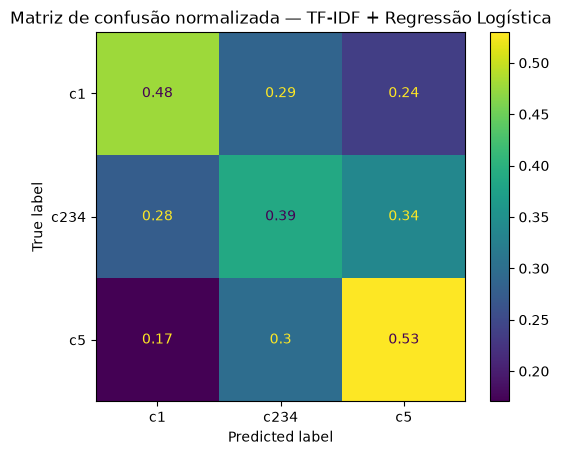

In [27]:
ConfusionMatrixDisplay.from_predictions(
    y_val,
    pred_baseline,
    labels=["c1", "c234", "c5"],
    normalize="true"
)

plt.title("Matriz de confusão normalizada — TF-IDF + Regressão Logística")
plt.show()

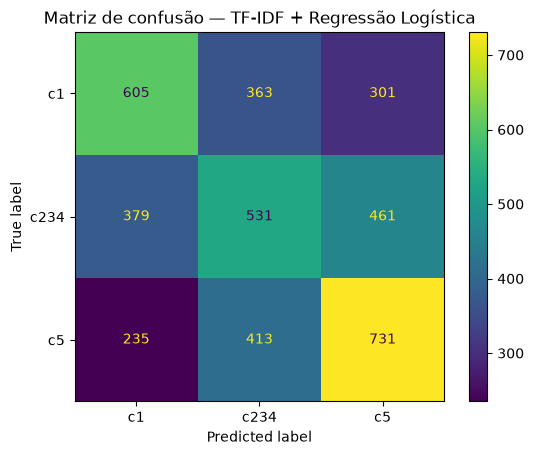

In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_val,
    pred_baseline,
    labels=["c1", "c234", "c5"],
    normalize=None
)

plt.title("Matriz de confusão — TF-IDF + Regressão Logística")
plt.show()

In [25]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_val,
        pred_baseline,
        labels=["c1", "c234", "c5"],
        digits=4
    )
)

              precision    recall  f1-score   support

          c1     0.4963    0.4768    0.4863      1269
        c234     0.4063    0.3873    0.3966      1371
          c5     0.4896    0.5301    0.5091      1379

    accuracy                         0.4645      4019
   macro avg     0.4641    0.4647    0.4640      4019
weighted avg     0.4633    0.4645    0.4635      4019



In [24]:
df["resp_text"] = df["resp_text"].astype(str)

In [23]:
pred_baseline = baseline.predict(X_val)

baseline_acc = accuracy_score(y_val, pred_baseline)

print(f"Accuracy classe majoritária: {dummy_acc:.4f}")
print(f"Accuracy TF-IDF + Logistic Regression: {baseline_acc:.4f}")

Accuracy classe majoritária: 0.3431
Accuracy TF-IDF + Logistic Regression: 0.4645


In [22]:
baseline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","['c1','c234','c5']"
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"max_df max_df: float or int, default=1.0When building the vocabulary ignore terms that have a documentfrequency strictly higher than the given threshold (corpus-specificstop words).If float in range [0.0, 1.0], the parameter represents a proportion ofdocuments, integer absolute counts.This parameter is ignored if vocabulary is not None.",0.98
,"min_df min_df: float or int, default=1When building the vocabulary ignore terms that have a documentfrequency strictly lower than the given threshold. This value is alsocalled cut-off in the literature.If float in range of [0.0, 1.0], the parameter represents a proportionof documents, integer absolute counts.This parameter is ignored if vocabulary is not None.",2
,"max_features max_features: int, default=NoneIf not None, build a vocabulary that only consider the top`max_features` ordered by term frequency across the corpus.Otherwise, all features are used.This parameter is ignored if vocabulary is not None.",100000
,"sublinear_tf sublinear_tf: bool, default=FalseApply sublinear tf scaling, i.e. replace tf with 1 + log(tf).",True


In [21]:
X_train = train_df["resp_text"].astype(str)
y_train = train_df["clarity"]

X_val = val_df["resp_text"].astype(str)
y_val = val_df["clarity"]

In [20]:
val_df["resp_text"].map(type).value_counts()

resp_text
<class 'str'>    4019
Name: count, dtype: int64

In [19]:
train_df["resp_text"].map(type).value_counts()

resp_text
<class 'str'>    16072
<class 'int'>        1
Name: count, dtype: int64

In [18]:
baseline.fit(X_train, y_train)

AttributeError: 'int' object has no attribute 'lower'

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

baseline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.98,
            sublinear_tf=True,
            max_features=100000
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=SEED
        )
    )
])

In [16]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

X_train = train_df["resp_text"]
y_train = train_df["clarity"]

X_val = val_df["resp_text"]
y_val = val_df["clarity"]

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)

pred_dummy = dummy.predict(X_val)

dummy_acc = accuracy_score(y_val, pred_dummy)

print(f"Accuracy classe majoritária: {dummy_acc:.4f}")

Accuracy classe majoritária: 0.3431


In [15]:
assert set(train_df["resp_text"]).isdisjoint(set(val_df["resp_text"]))

print("OK: nenhum texto idêntico aparece simultaneamente em treino e validação.")
print("Treino:", len(train_df))
print("Validação:", len(val_df))

OK: nenhum texto idêntico aparece simultaneamente em treino e validação.
Treino: 16073
Validação: 4019


In [14]:
textos_treino = set(train_df["resp_text"])
textos_validacao = set(val_df["resp_text"])

print(
    "Textos idênticos presentes em treino e validação:",
    len(textos_treino.intersection(textos_validacao))
)

Textos idênticos presentes em treino e validação: 0


In [13]:
print("TREINO")
print(train_df["clarity"].value_counts())
print()
print(train_df["clarity"].value_counts(normalize=True).round(4))

print("\nVALIDAÇÃO")
print(val_df["clarity"].value_counts())
print()
print(val_df["clarity"].value_counts(normalize=True).round(4))

TREINO
clarity
c5      5513
c234    5482
c1      5078
Name: count, dtype: int64

clarity
c5      0.3430
c234    0.3411
c1      0.3159
Name: proportion, dtype: float64

VALIDAÇÃO
clarity
c5      1379
c234    1371
c1      1269
Name: count, dtype: int64

clarity
c5      0.3431
c234    0.3411
c1      0.3158
Name: proportion, dtype: float64


In [12]:
grupos_treino = set(train_df["text_group"])
grupos_validacao = set(val_df["text_group"])

intersecao = grupos_treino.intersection(grupos_validacao)

print("Grupos presentes nos dois conjuntos:", len(intersecao))

Grupos presentes nos dois conjuntos: 0


In [11]:
from sklearn.model_selection import StratifiedGroupKFold

SEED = 42

# Cada texto idêntico recebe o mesmo identificador de grupo
df["text_group"] = pd.factorize(df["resp_text"])[0]

sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

train_idx, val_idx = next(
    sgkf.split(
        X=df,
        y=df["clarity"],
        groups=df["text_group"]
    )
)

train_df = df.iloc[train_idx].copy()
val_df = df.iloc[val_idx].copy()

print("Treino:", train_df.shape)
print("Validação:", val_df.shape)

Treino: (16073, 5)
Validação: (4019, 5)


In [10]:
textos_conflitantes = labels_por_texto[
    labels_por_texto > 1
].index

df[
    df["resp_text"].isin(textos_conflitantes)
].sort_values("resp_text")[["resp_text", "clarity"]].head(20)

,resp_text,clarity
15151,Boa tarde. A resposta para sua solicitação s...,c5
7308,Boa tarde. A resposta para sua solicitação s...,c5
16114,Boa tarde. A resposta para sua solicitação s...,c5
8774,Boa tarde. A resposta para sua solicitação s...,c5
11615,Boa tarde. A resposta para sua solicitação s...,c234
9939,Boa tarde. A resposta para sua solicitação s...,c234
15181,Boa tarde. A resposta para sua solicitação s...,c1
10171,Boa tarde. A resposta para sua solicitação s...,c234
2031,Boa tarde. A resposta para sua solicitação s...,c1
13090,Boa tarde. A resposta para sua solicitação s...,c1


In [9]:
labels_por_texto = (
    df.groupby("resp_text")["clarity"]
      .nunique()
)

n_conflitantes = (labels_por_texto > 1).sum()

print("Textos idênticos com mais de um rótulo:", n_conflitantes)

Textos idênticos com mais de um rótulo: 291


In [8]:
n_duplicados = df.duplicated(subset="resp_text").sum()

print("Ocorrências duplicadas adicionais:", n_duplicados)
print("Textos únicos:", df["resp_text"].nunique())

Ocorrências duplicadas adicionais: 1660
Textos únicos: 18432


In [7]:
df.groupby("clarity")[["n_chars", "n_words"]].agg(
    ["mean", "median"]
).round(1)

n_chars        n_words       
           mean median    mean median
clarity                              
c1       1055.4  782.0   152.4  111.0
c234     1089.5  794.0   157.1  112.0
c5        861.1  606.5   124.1   87.0

In [6]:
df["n_chars"] = df["resp_text"].astype(str).str.len()
df["n_words"] = df["resp_text"].astype(str).str.split().str.len()

df[["n_chars", "n_words"]].describe()

,n_chars,n_words
count,20092.000000,20092.000000
mean,1000.381644,144.274288
std,1014.001503,149.866288
min,7.000000,1.000000
25%,338.000000,47.000000
50%,709.000000,101.000000
75%,1311.000000,188.000000
max,12125.000000,1821.000000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20092 entries, 0 to 20091
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   resp_text  20092 non-null  object
 1   clarity    20092 non-null  str   
dtypes: object(1), str(1)
memory usage: 366.7+ KB


In [ ]:
print("Valores ausentes:")
print(df.isna().sum())

print("\nDistribuição das classes:")
print(df["clarity"].value_counts())

print("\nProporção das classes:")
print(df["clarity"].value_counts(normalize=True).round(4))

In [ ]:
df.info

In [ ]:
import pandas as pd
from pathlib import Path

DATA_PATH = Path("../data/train.xlsx")

df = pd.read_excel(DATA_PATH)

print("Dimensões:", df.shape)
print("Colunas:", df.columns.tolist())

df.head()

In [ ]:
import sys
import torch

print("Python:", sys.executable)
print("CUDA disponível:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))